In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('../factorised-MA-AIF/')

from games import *
# from agent import Agent
from network_agent import NetworkAgent
import utils.simulation

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [18]:
available_games = {
    # 'Ch': chicken_2player, 
    # 'PD': prisoners_dilemma_2player, 
    'SH': stag_hunt_2player, 
    # 'Ha': harmony_2player
}

def get_game_name(this_game, available_games):
    for key, game in available_games.items():
        if torch.equal(this_game, game):
            return key
    return None

Simulation: n=20 agents playing 44 games
(0, 1) -- SH
(0, 6) -- SH
(0, 8) -- SH
(0, 10) -- SH
(0, 15) -- SH
(0, 16) -- SH
(1, 7) -- SH
(1, 12) -- SH
(2, 6) -- SH
(2, 10) -- SH
(2, 18) -- SH
(2, 19) -- SH
(3, 11) -- SH
(3, 15) -- SH
(3, 16) -- SH
(4, 11) -- SH
(4, 17) -- SH
(4, 18) -- SH
(5, 10) -- SH
(5, 14) -- SH
(5, 16) -- SH
(6, 9) -- SH
(6, 16) -- SH
(7, 9) -- SH
(7, 12) -- SH
(8, 15) -- SH
(8, 16) -- SH
(8, 19) -- SH
(9, 11) -- SH
(9, 12) -- SH
(9, 13) -- SH
(10, 16) -- SH
(11, 13) -- SH
(11, 16) -- SH
(11, 19) -- SH
(12, 13) -- SH
(12, 15) -- SH
(12, 16) -- SH
(12, 19) -- SH
(13, 16) -- SH
(13, 19) -- SH
(14, 15) -- SH
(15, 18) -- SH
(15, 19) -- SH


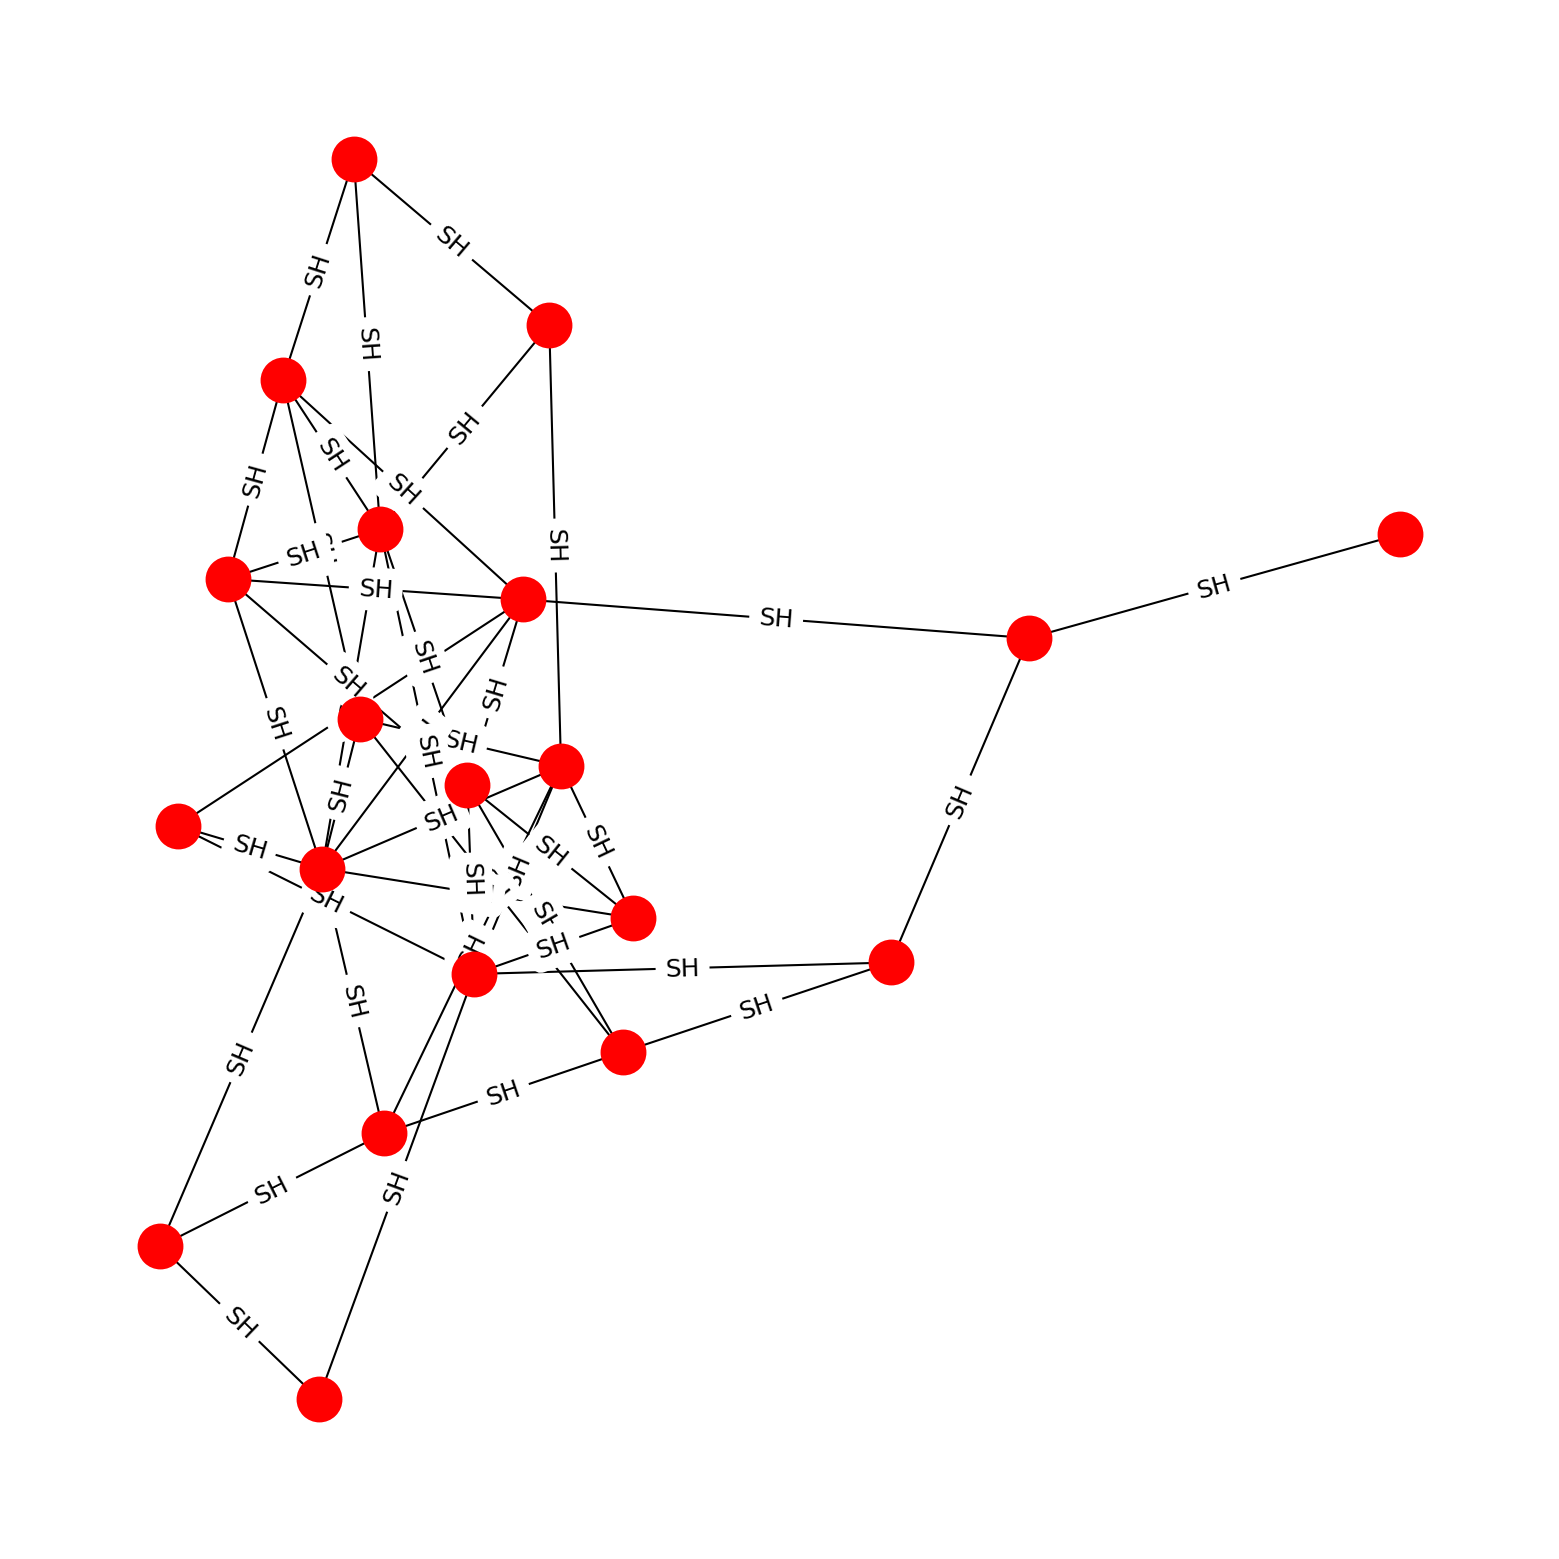

In [19]:
# Predefined constants
n = 20  # Number of nodes
p = 0.2  # Probability of edge creation

# Generate an Erdős-Rényi network
G = nx.erdos_renyi_graph(n, p)

# Assign a random game to each edge in the graph
for edge in G.edges:
    G.edges[edge]['game'] = list(available_games.values())[np.random.randint(len(available_games))]

# List the edges and their corresponding games
print(f"Simulation: n={G.number_of_nodes()} agents playing {G.number_of_edges()} games")
for edge in G.edges(data=True):
    game = edge[2]['game']
    game_name = get_game_name(game, available_games)
    print(f"{edge[:2]} -- {game_name}")

# Plot the network
plt.figure(figsize=(5, 5), dpi=150)
pos = nx.spring_layout(G)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color='red', 
    edge_color='black', 
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [24]:
T = 500
num_players = len(G.nodes)  # Number of players (nodes in the graph)

agent_kwargs = [                                                                # <--- Define agent configurations here
    dict(
        beta_1=300.,
        dynamic_precision=True,
        decay=0.9,
        A_learning=False,
        learn_every_t_steps=30,
        learning_offset=8,
    )
] * num_players

# Initialisation ---------------------------------------------------------------
agents = []
for node in G.nodes:
    adjacent_games = [G.edges[edge]['game'] for edge in G.edges(node)]
    agents.append(
        NetworkAgent(
            id=node, 
            game_matrices=adjacent_games, 
            **agent_kwargs[node]
        )
    )

# Instantiate the simulator object
ig = utils.simulation.IteratedNetworkGame(agents=agents, network=G, seed=None)

# Simulation -------------------------------------------------------------------
variables_history = ig.run(T)

INFO:root:Simulation started with seed 78
INFO:root:t=0/500
INFO:root:t=0/500
INFO:root:t=200/500
INFO:root:t=400/500
INFO:root:t=500/500 Simulation complete


## Plotting

Text(0, 0.5, 'q_u')

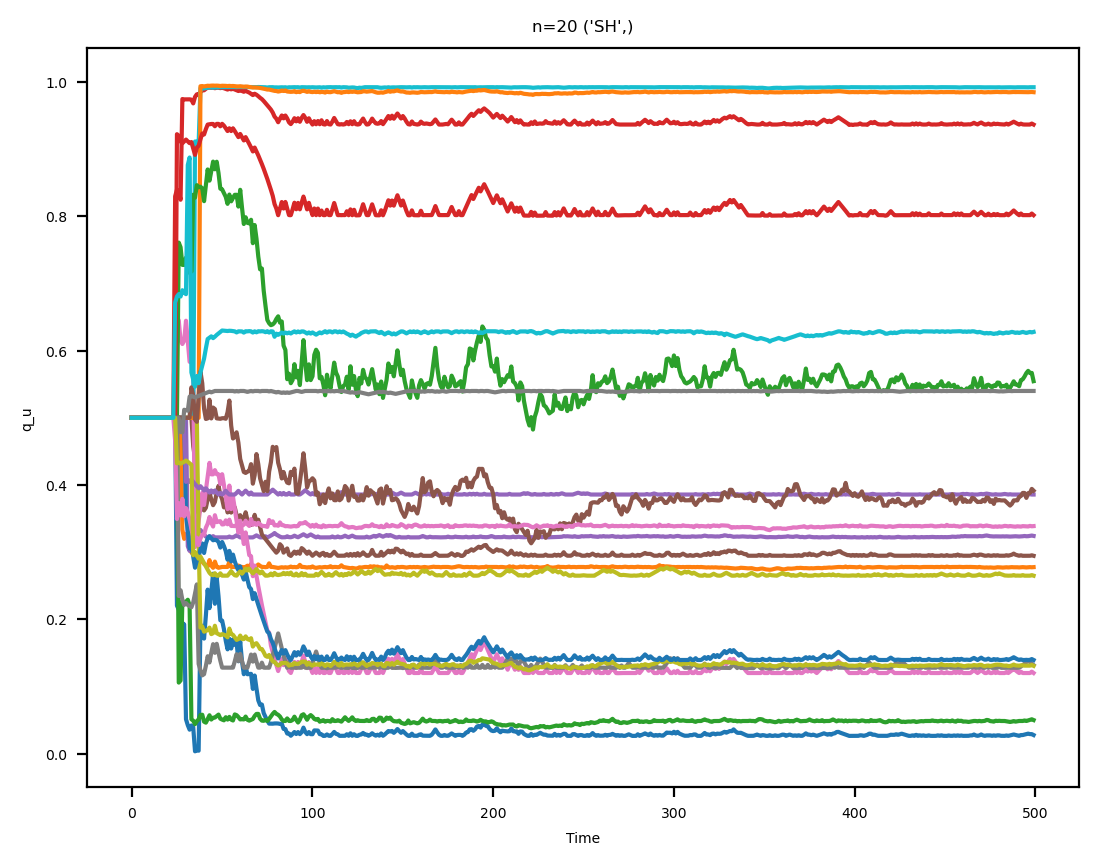

In [25]:
MARGIN = 0.05
q_u_history = np.array(variables_history['q_u'])
for i in range(num_players):
    plt.plot(q_u_history[:, i, 0], label='Agent 0')  # indices: time, agent, action
plt.ylim(0-MARGIN, 1+MARGIN)
plt.title(f'n={len(G.nodes)} {tuple(available_games.keys())}')
plt.xlabel('Time')
plt.ylabel('q_u')

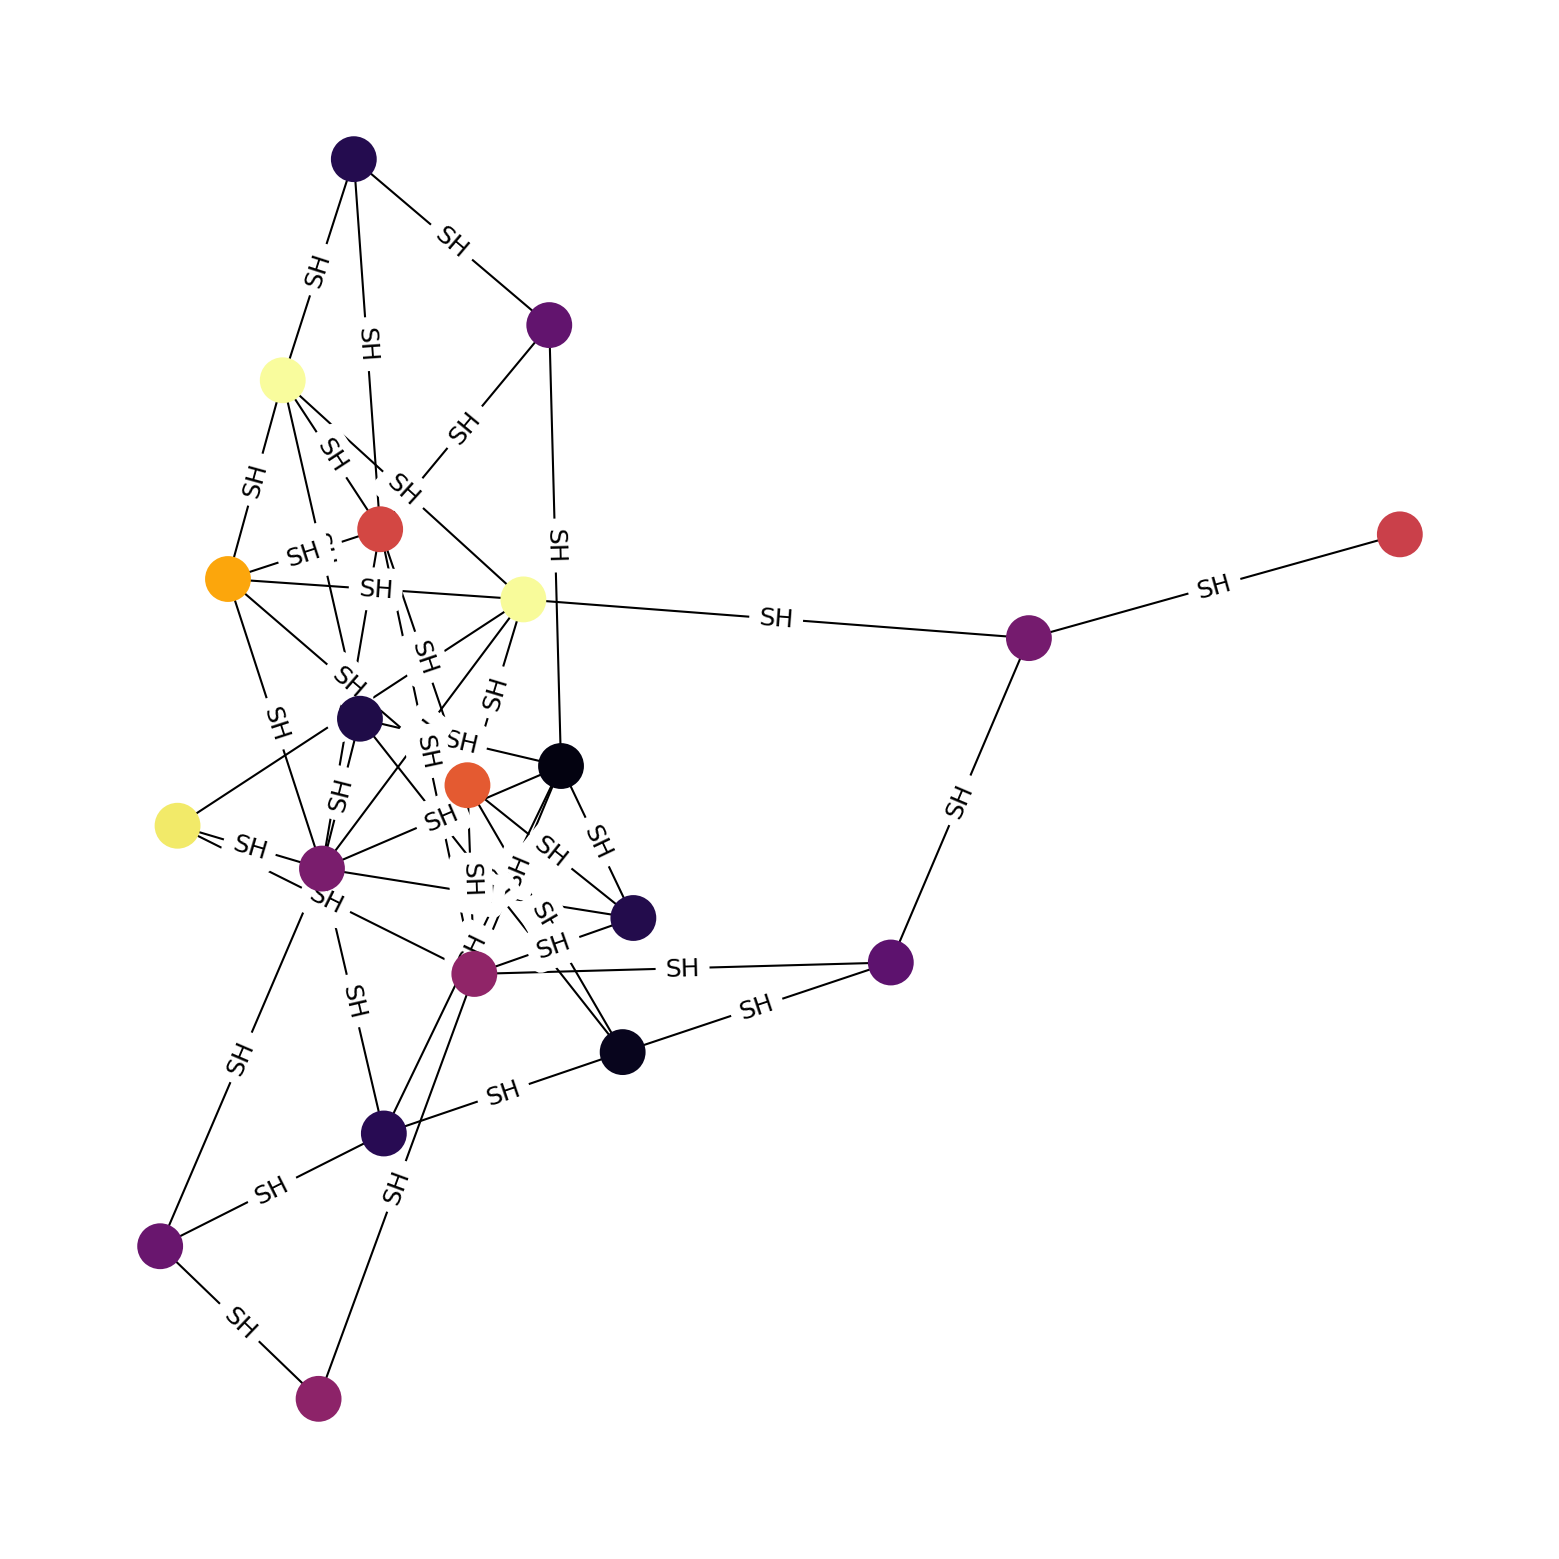

In [26]:
node_intensity = q_u_history[-2, :, 0]  # Extract node intensities
plt.figure(figsize=(5, 5), dpi=150)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=100, 
    node_color=node_intensity, 
    vmin=0, 
    vmax=1, 
    edge_color='black', 
    cmap=plt.cm.inferno,
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

['accuracy', 'complexity', 'energy', 'entropy', 'ambiguity', 'risk', 'salience', 'pragmatic_value', 'novelty', 'precision']


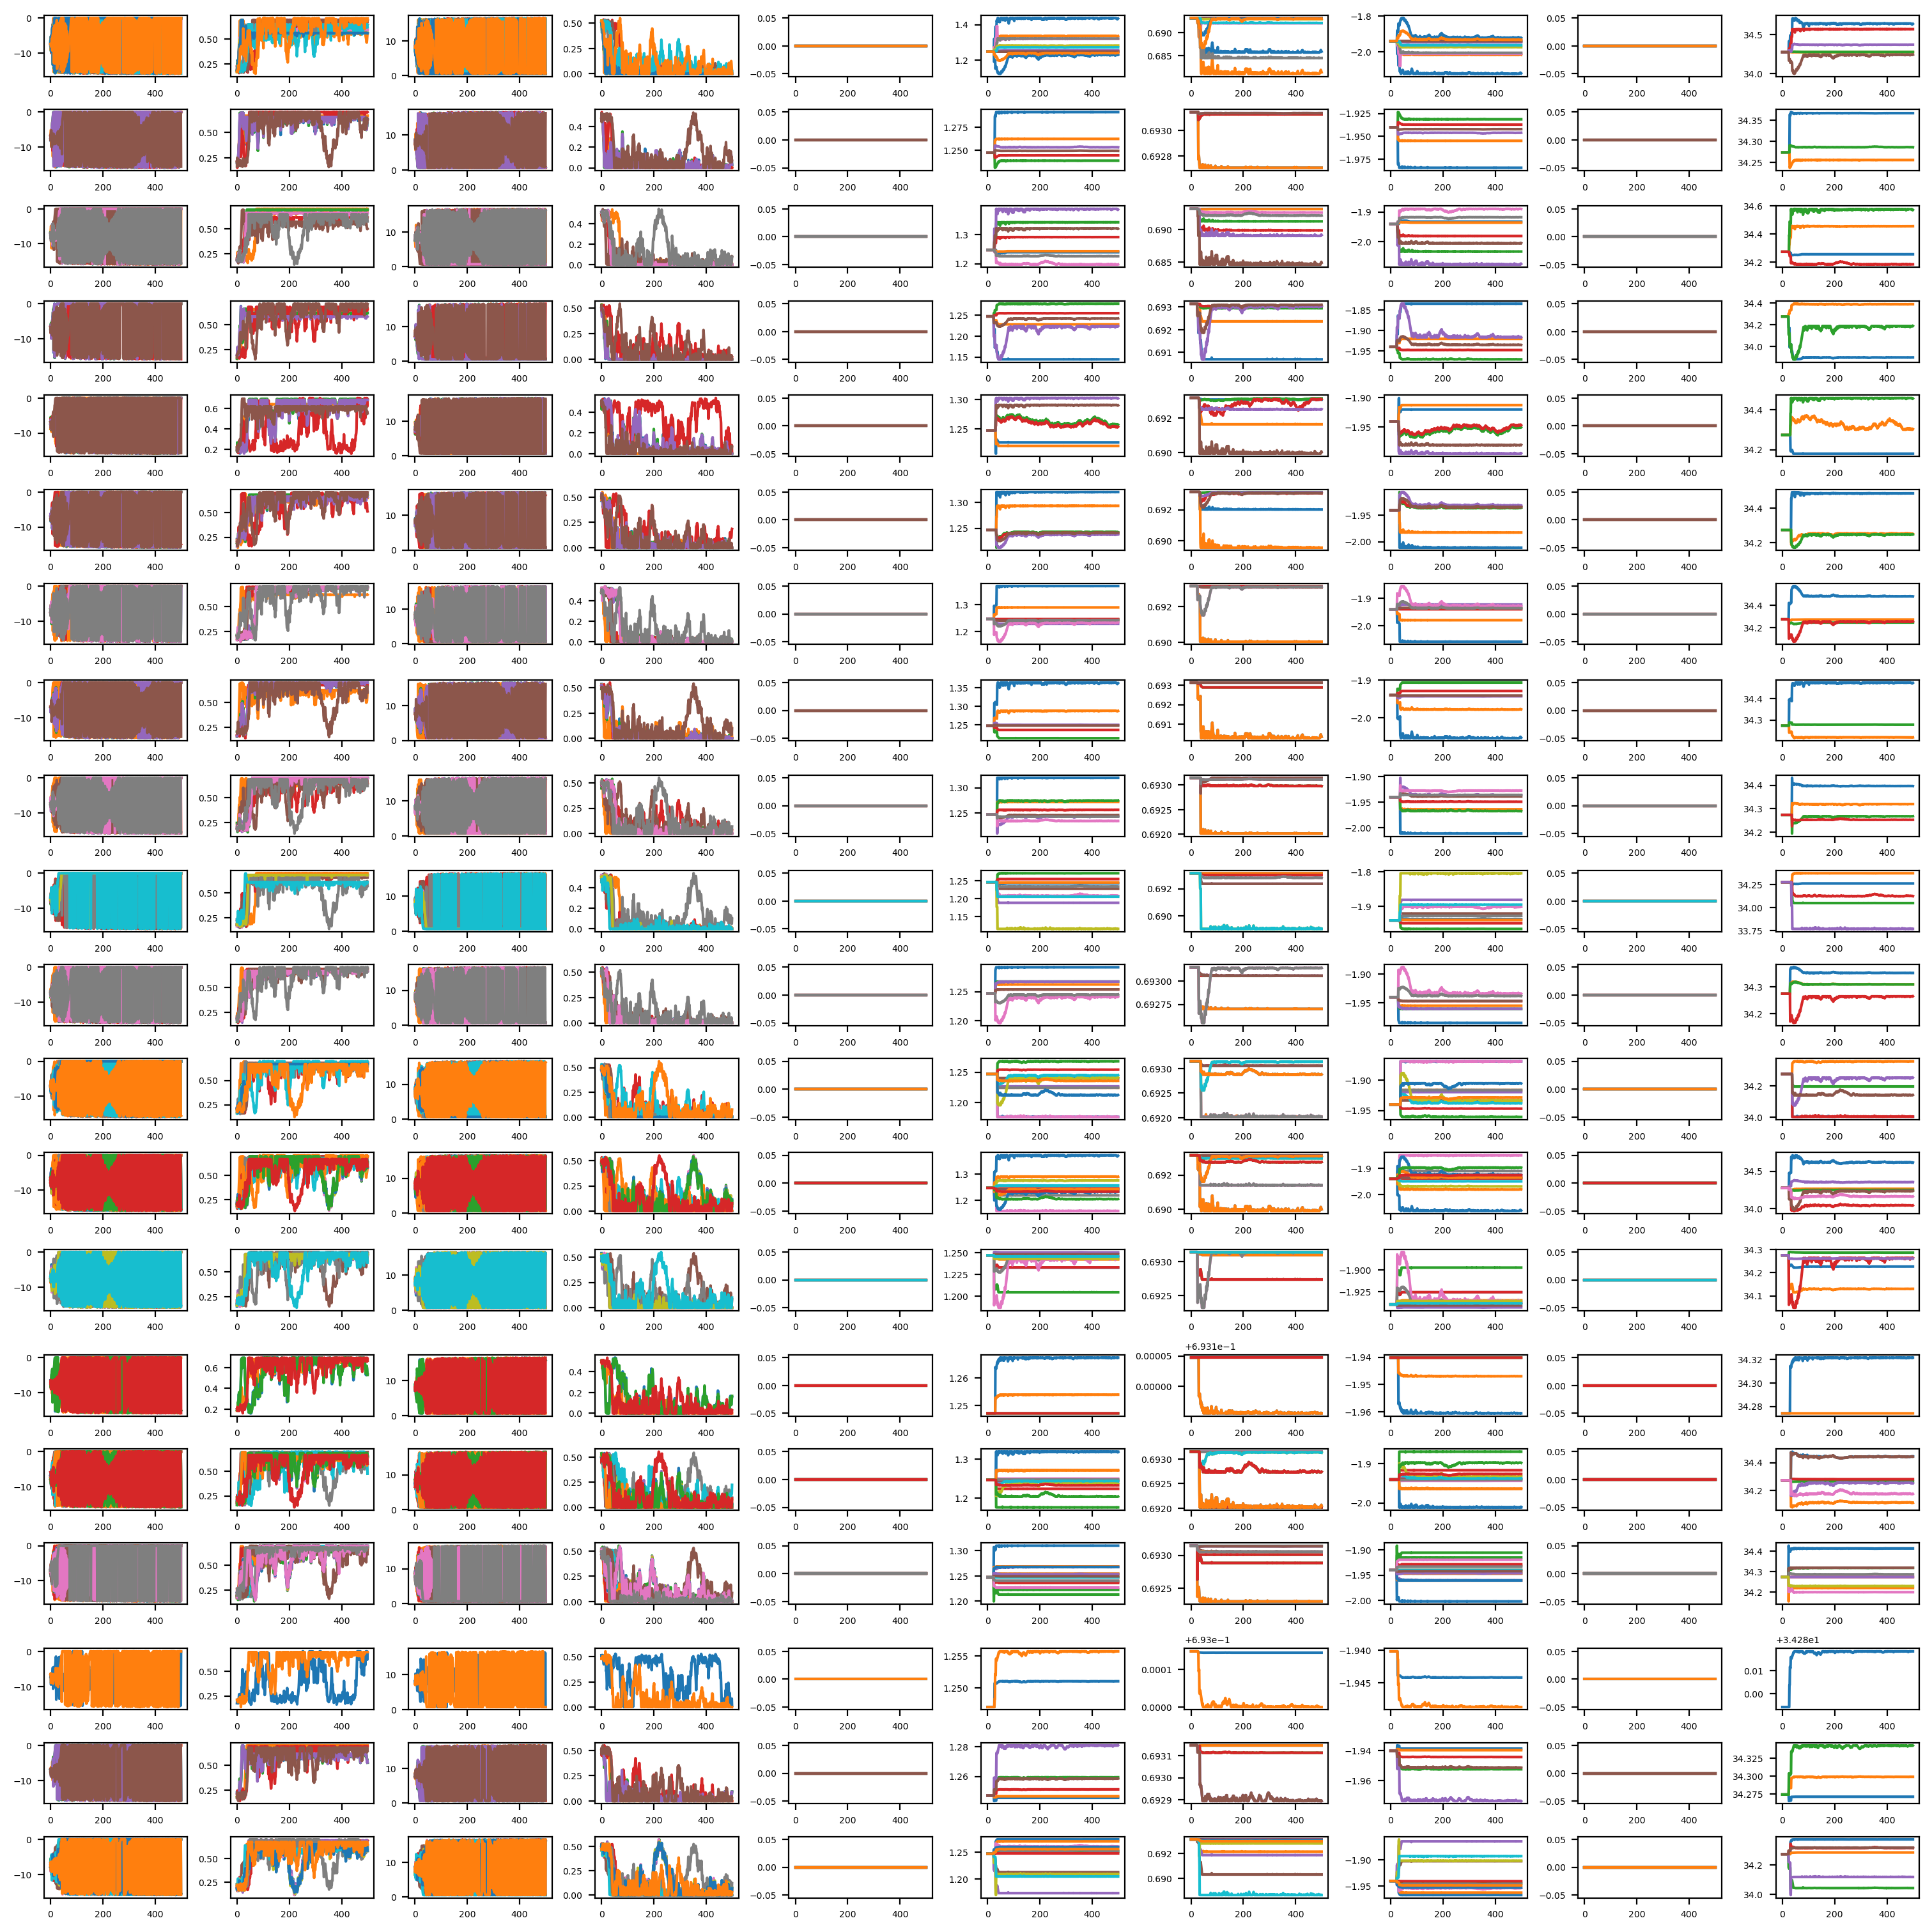

In [27]:
variable_names = list(variables_history['generative_models_data'][0][0][0].keys())
# variable_name = 'complexity'

plt.rc('font', size=5)
fig, axs = plt.subplots(
    num_players, 
    len(variable_names), 
    figsize=(15, 15), 
    constrained_layout=True
)
axs = axs.flatten()
for idx, ax in enumerate(axs):
    variable_name = variable_names[idx%len(variable_names)]
    i = idx // len(variable_names)

    data = []
    for t in range(T):
        data.append([
            game[variable_name]
            for game in variables_history['generative_models_data'][t][i]
        ])

    data = np.array(data)

    for j in range(data.shape[1]):
        ax.plot(data[:, j], label=f'Agent {j}')

print(variable_names)

In [47]:
from itertools import combinations

L_max = 2  # number of hops
# superagent_max_size = 3
superagents = []
for node in G.nodes:
    # Get all neighbors within L_max hops
    neighbors = nx.single_source_shortest_path_length(G, node, cutoff=L_max)
    # Get all combinations of edges at distance l
    for l in range(1, L_max + 1):
        edges_at_distance_l = [
            tuple(sorted([node, neighbor])) 
            for neighbor, distance in neighbors.items() 
            if distance == l
        ]
        combinations_at_distance_l = []
        for superagent_size in range(1, len(edges_at_distance_l) + 1):
            combinations_at_distance_l += \
                list(combinations(edges_at_distance_l, superagent_size))
        # Filter out combinations that are already in superagents
        superagents += [
            combination for combination in combinations_at_distance_l 
            if combination not in superagents
        ]

superagents

[((0, 1),),
 ((0, 6),),
 ((0, 8),),
 ((0, 10),),
 ((0, 15),),
 ((0, 16),),
 ((0, 1), (0, 6)),
 ((0, 1), (0, 8)),
 ((0, 1), (0, 10)),
 ((0, 1), (0, 15)),
 ((0, 1), (0, 16)),
 ((0, 6), (0, 8)),
 ((0, 6), (0, 10)),
 ((0, 6), (0, 15)),
 ((0, 6), (0, 16)),
 ((0, 8), (0, 10)),
 ((0, 8), (0, 15)),
 ((0, 8), (0, 16)),
 ((0, 10), (0, 15)),
 ((0, 10), (0, 16)),
 ((0, 15), (0, 16)),
 ((0, 1), (0, 6), (0, 8)),
 ((0, 1), (0, 6), (0, 10)),
 ((0, 1), (0, 6), (0, 15)),
 ((0, 1), (0, 6), (0, 16)),
 ((0, 1), (0, 8), (0, 10)),
 ((0, 1), (0, 8), (0, 15)),
 ((0, 1), (0, 8), (0, 16)),
 ((0, 1), (0, 10), (0, 15)),
 ((0, 1), (0, 10), (0, 16)),
 ((0, 1), (0, 15), (0, 16)),
 ((0, 6), (0, 8), (0, 10)),
 ((0, 6), (0, 8), (0, 15)),
 ((0, 6), (0, 8), (0, 16)),
 ((0, 6), (0, 10), (0, 15)),
 ((0, 6), (0, 10), (0, 16)),
 ((0, 6), (0, 15), (0, 16)),
 ((0, 8), (0, 10), (0, 15)),
 ((0, 8), (0, 10), (0, 16)),
 ((0, 8), (0, 15), (0, 16)),
 ((0, 10), (0, 15), (0, 16)),
 ((0, 1), (0, 6), (0, 8), (0, 10)),
 ((0, 1), (0, 6), (

## Superagents

In [40]:
tuple(sorted([3, 1]))

(1, 3)